<a href="https://colab.research.google.com/github/abeeraz379/Prediction-of-Product-sales/blob/main/prediction%20of%20product%20sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction for product sales
 - ABeer Al-Zebda | Data Scientist


# Project Overview

**This project analyzes a Product Sales dataset by first inspecting and cleaning the data to prepare it for visualization. We then perform exploratory data analysis (EDA) to identify correlations, create plots to uncover patterns, and derive key insights. The primary goal is to build a predictive model for Product Sales and use the findings to inform strategies for increasing property values.**

**Data Link:** https://www.analyticsvidhya.com/datahack/contest/practice-problem-big-mart-sales-iii/

#Load and inspect data

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
path='/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df= pd.read_csv(path)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [2]:
# to know more about data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Data Set info
- number of column :12
- number of rows :8522

 ## Types of Columns
- 7 Categorical Columns
- 1 int Column
- 4 float Columns   

#Clean Data

## Check for duplicates

In [3]:
df.duplicated(keep=False).sum()

np.int64(0)

## Check for Missing Values

In [3]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


## Missing Values Rate

In [4]:
df.isna().sum()/len(df)*100

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


## Handling Missing Value

In [5]:
# using describe to see the statstical info for Item_Weight
df['Item_Weight'].describe()

,Item_Weight
count,7060.000000
mean,12.857645
std,4.643456
min,4.555000
25%,8.773750
50%,12.600000
75%,16.850000
max,21.350000


In [6]:
df['Item_Weight'].value_counts()

,count
Item_Weight,
12.150,86
17.600,82
13.650,77
11.800,76
15.100,68
...,...
8.920,2
6.520,1
9.420,1


In [11]:
# fill the missing value with placeholder = -1
df['Item_Weight']=df['Item_Weight'].fillna(-1 )
df['Item_Weight'].isna().sum()

np.int64(0)

In [9]:
# search for the most frequency value
df['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


In [8]:
# handle the missing value with Placeholder Missing
df['Outlet_Size']=df['Outlet_Size'].fillna('Missing')
df['Outlet_Size'].isna().sum()


np.int64(0)

In [12]:
# check that there is no missing value anymore
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


<Axes: >

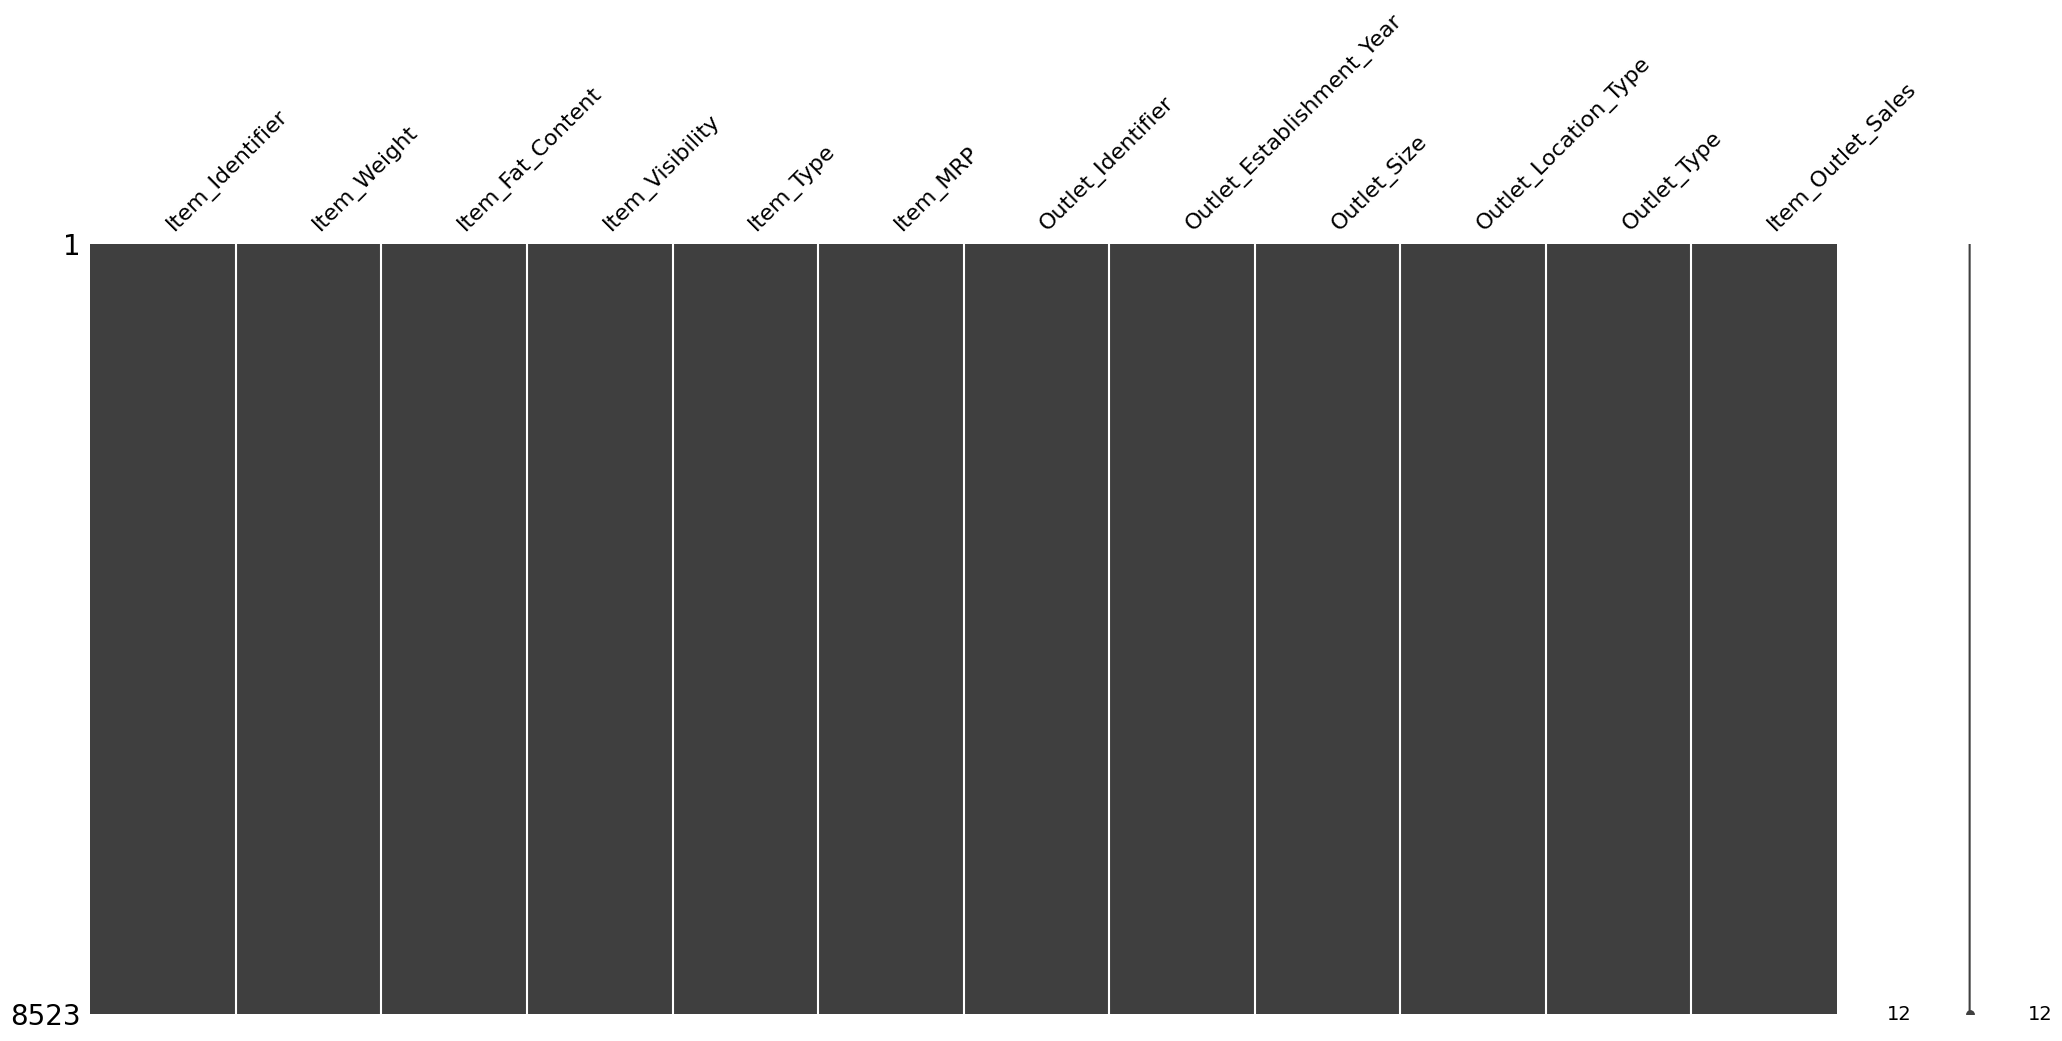

In [12]:
import missingno as msno
msno.matrix(df)

## Check Consistancy

In [13]:
# see the values for each column with it frequency to check the consistancy
for col in df.columns:
  print( df[col].value_counts())
  print('\n')

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Item_Weight
-1.000     1463
 12.150      86
 17.600      82
 13.650      77
 11.800      76
           ... 
 5.210        2
 9.420        1
 7.685        1
 5.400        1
 6.520        1
Name: count, Length: 416, dtype: int64


Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Item_Visibility
0.000000    526
0.076975      3
0.061271      2
0.046825      2
0.112399      2
           ... 
0.054142      1
0.018920      1
0.044974      1
0.103611      1
0.083060      1
Name: count, Length: 7880, dtype: int64


Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
He

## Handling inconstancy

In [16]:
# replace the inconstancy values with the right values
df['Item_Fat_Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})

,Item_Fat_Content
0,Low Fat
1,Regular
2,Low Fat
3,Regular
4,Low Fat
...,...
8518,Low Fat
8519,Regular
8520,Low Fat
8521,Regular


In [17]:
# check to make sure that data now is clean
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


## Save the clean data

In [18]:
# save the clean data into new file called cleaning product sales using to_csv
fpath='/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week03/Data/Cleaning_ProductSales.csv'
new_df=df.to_csv(fpath,index=False)


In [19]:
new_df=pd.read_csv(fpath)
new_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Missing,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


#Exploratory Data Analysis

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Histogram Plot

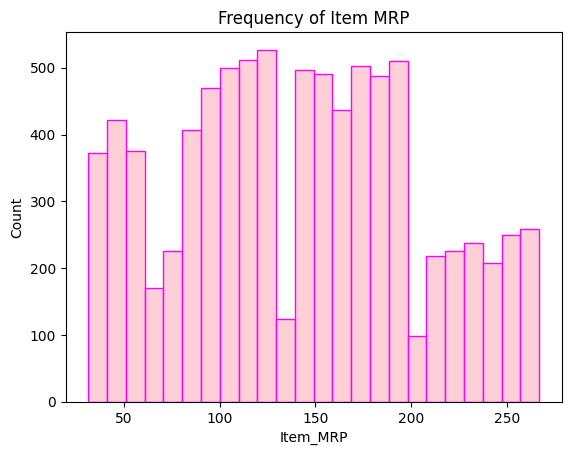

In [21]:
# make histogram for Item MRP
ax =sns.histplot(data=new_df, x='Item_MRP',binwidth=10,color='Pink',edgecolor='#FF00FF')
ax.ticklabel_format(style='plain', axis='x')
ax.set_title('Frequency of Item MRP');

## Box Plot

In [22]:
# To know more info about Outlet_Establishment_Year column using describe
df['Outlet_Establishment_Year'].describe()

,Outlet_Establishment_Year
count,8523.000000
mean,1997.831867
std,8.371760
min,1985.000000
25%,1987.000000
50%,1999.000000
75%,2004.000000
max,2009.000000


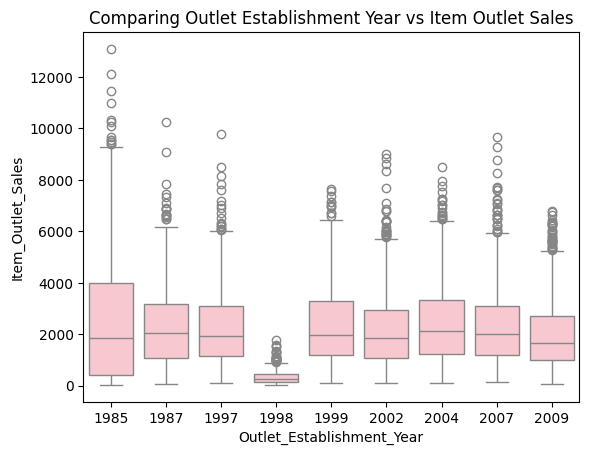

In [23]:
# make a Boxplot for Comparing Outlet Establishment Year vs Item Outlet Sales
ax=sns.boxplot(data=new_df, y='Item_Outlet_Sales', x='Outlet_Establishment_Year',color='Pink')
ax.set_title('Comparing Outlet Establishment Year vs Item Outlet Sales');

## Count Plot

In [24]:
# Using select_dtypes to get categorical columns
cat_cols=df.select_dtypes(include='object').columns
cat_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [25]:
# check how many categories in each column of cat_cols
for col in cat_cols:
  print(col)
  print(df[col].value_counts())

Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64
Item_Fat_Content
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64
Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Na

/tmp/ipykernel_346/3456389465.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1][1].set_xticklabels(ax[1][1].get_xticklabels(),rotation=90);


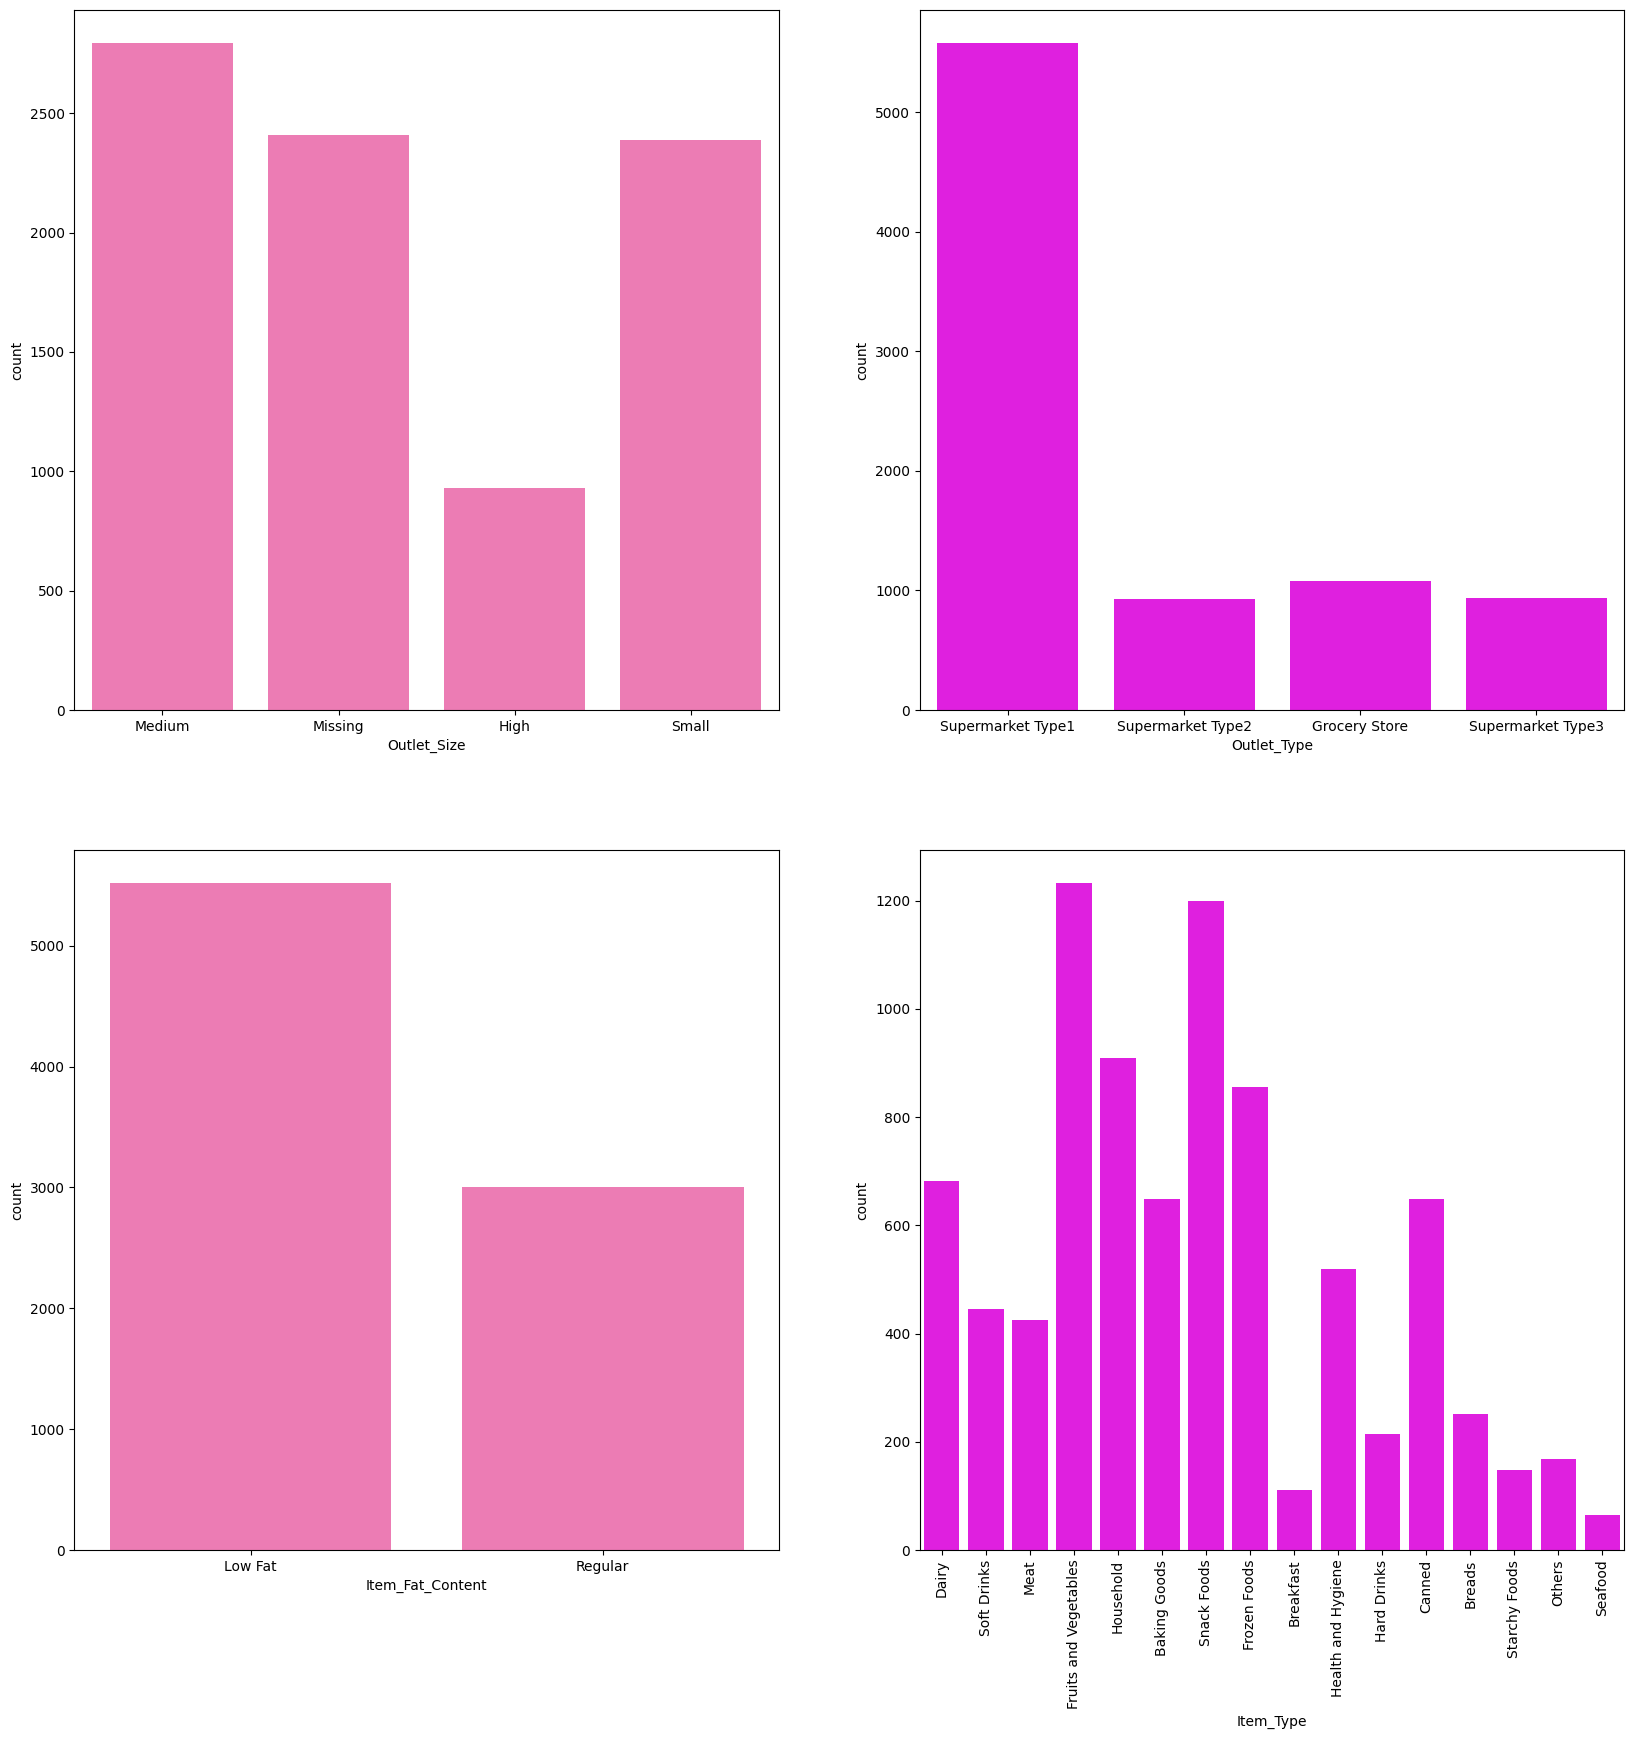

In [26]:
# make a count plots for the categorical columns
fig,ax=plt.subplots(ncols=2,nrows=2,figsize=(20,20))
ax[0][0]=sns.countplot(x='Outlet_Size',data=new_df,ax=ax[0][0],color='#FF69B4')
ax[0][0].set_title='count of Outlet Size'

ax[0][1]=sns.countplot(x='Outlet_Type',data=new_df,ax=ax[0][1],color='#FF00FF')
ax[0][1].set_title='count of Outlet Type'

ax[1][0]=sns.countplot(x='Item_Fat_Content',data=new_df,ax=ax[1][0],color='#FF69B4')
ax[1][0].set_title='count of Item Fat Content'

ax[1][1]=sns.countplot(x='Item_Type',data=new_df,ax=ax[1][1],color='#FF00FF')
ax[1][1].set_title='count of Item Type'
ax[1][1].set_xticklabels(ax[1][1].get_xticklabels(),rotation=90);

## Heat Map Plot

<Axes: >

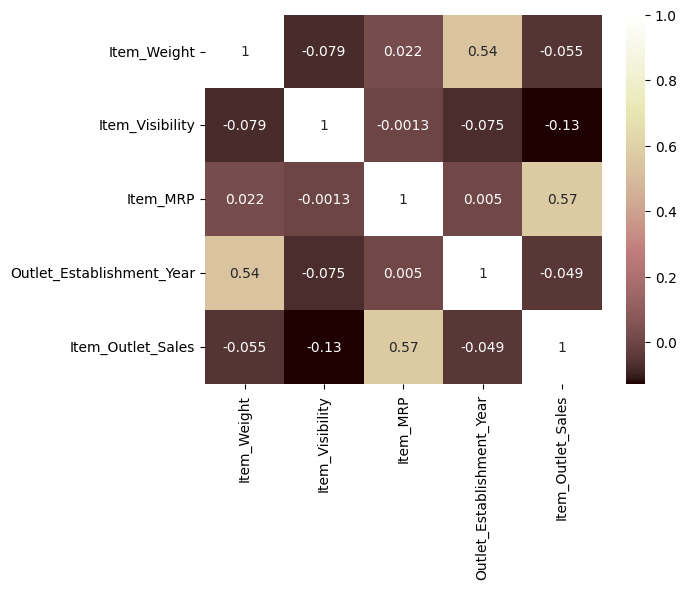

In [27]:
# make heatmap for correlation
crr=df.corr(numeric_only=True)
sns.heatmap(crr,annot=True,cmap="pink")

#Future Inspection